# ICU Deterioration Dataset EDA

This notebook performs exploratory data analysis for parquet data in `mimic_processed/` and loads the feature list from CSV. Run cells top to bottom.

In [1]:
# Optional: install dependencies if needed
%pip install -q pandas numpy matplotlib seaborn missingno

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

try:
    import missingno as msno
except Exception:
    msno = None

print('Imports loaded')

Imports loaded


In [10]:
# Find parquet dataset and CSV feature list under mimic_processed
base_dir = os.path.join(os.getcwd(), 'mimic_processed')
parquet_candidates = sorted(glob.glob(os.path.join(base_dir, '*.parquet')))
if not parquet_candidates:
    parquet_candidates = sorted(glob.glob(os.path.join(base_dir, '**', '*.parquet'), recursive=True))

feature_list_candidates = sorted(glob.glob(os.path.join(base_dir, '*feature_list*.csv')))
if not feature_list_candidates:
    feature_list_candidates = sorted(glob.glob(os.path.join(base_dir, '**', '*feature_list*.csv'), recursive=True))

if not parquet_candidates:
    raise FileNotFoundError('No parquet file found in mimic_processed/.')

data_path = next((p for p in parquet_candidates if 'feature_matrix_raw' in os.path.basename(p)), parquet_candidates[0])
print('Using parquet file:', data_path)
df = pd.read_parquet(data_path)

feature_list = None
if feature_list_candidates:
    feature_list_path = feature_list_candidates[0]
    print('Using feature list CSV:', feature_list_path)
    feature_list = pd.read_csv(feature_list_path)
else:
    print('No feature list CSV found.')

df.shape

Using parquet file: c:\Users\21270\Desktop\ICU Deterioration Detection Project\mimic_processed\08_feature_matrix_raw_20260528_1247.parquet
Using feature list CSV: c:\Users\21270\Desktop\ICU Deterioration Detection Project\mimic_processed\10_feature_list_20260528_1247.csv


(42837, 153)

In [15]:
# Basic overview
display(df.head())
print('Rows, Cols:', df.shape)
print('Columns:', len(df.columns))
display(df.dtypes)
display(df.describe(include='all').T)
if feature_list is not None:
    print('Feature list shape:', feature_list.shape)
    display(feature_list.head())

print('Total feature count:', len(df.columns))

,stay_id,intime,label,age,pre_icu_hours,los_days,gender_male,emergency_flag,unit_micu,unit_sicu,...,lab_glucose_was_missing,total_input_ml,total_urine_ml,urine_n_obs,fluid_balance_ml,urine_rate_ml_hr,fluid_negative_flag,oliguria_flag,vaso_flag,vaso_max_rate
0,39753527,2110-01-14 07:22:00,0,60,2.08,1.2407,1,0,0,0,...,0,6629.999965,2925.0,6,3704.999965,121.875000,0,0,0,0.0
1,30471766,2110-01-14 18:07:20,1,83,0.02,4.9804,1,0,0,0,...,0,525.979458,2520.0,9,-1994.020542,105.000000,1,0,0,0.0
2,31337458,2110-01-16 04:28:00,0,26,0.40,1.5577,1,0,0,0,...,0,4025.592838,1615.0,12,2410.592838,67.291667,0,0,0,0.0
3,32140208,2110-01-17 00:28:00,0,84,0.85,1.0371,1,0,0,0,...,0,1431.666670,810.0,4,621.666670,33.750000,0,1,0,0.0
4,37546608,2110-01-20 14:01:00,0,52,0.03,1.1392,0,0,0,0,...,0,5839.583346,3345.0,20,2494.583346,139.375000,0,0,0,0.0


Rows, Cols: (42837, 153)
Columns: 153


stay_id                         Int64
intime                 datetime64[us]
label                           int64
age                             Int64
pre_icu_hours                 float64
                            ...      
urine_rate_ml_hr              float64
fluid_negative_flag             int64
oliguria_flag                   int64
vaso_flag                       int64
vaso_max_rate                 float64
Length: 153, dtype: object

,count,mean,min,25%,50%,75%,max,std
stay_id,42837.0,34982463.765553,30000153.0,32506507.0,34971254.0,37455075.0,39999858.0,2882403.264861
intime,42837,2154-03-01 15:19:38.575530,2110-01-14 07:22:00,2134-04-15 04:55:00,2154-02-28 07:07:00,2174-03-24 10:27:44,2214-07-22 17:05:53,NaN
label,42837.0,0.040853,0.0,0.0,0.0,0.0,1.0,0.197951
age,42837.0,63.096832,18.0,53.0,65.0,76.0,91.0,16.987998
pre_icu_hours,42837.0,58.24632,-245.12,0.97,2.12,28.13,9181.35,189.00248
...,...,...,...,...,...,...,...,...
urine_rate_ml_hr,40495.0,76.160834,0.0,40.0,65.416667,100.208333,2212.5,53.480692
fluid_negative_flag,42837.0,0.393772,0.0,0.0,0.0,1.0,1.0,0.488591
oliguria_flag,42837.0,0.186661,0.0,0.0,0.0,0.0,1.0,0.389644
vaso_flag,42837.0,0.012886,0.0,0.0,0.0,0.0,1.0,0.112784


Feature list shape: (150, 1)


,feature
0,age
1,pre_icu_hours
2,los_days
3,gender_male
4,emergency_flag


Total feature count: 153


In [16]:
# Missingness table
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_count / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct
})
display(missing_df[missing_df['missing_count'] > 0].head(50))

,missing_count,missing_pct
temp_c_std,41307,96.43
temp_c_max,41180,96.13
temp_c_n_obs,41180,96.13
temp_c_min,41180,96.13
temp_c_mean,41180,96.13
temp_c_first,41180,96.13
temp_c_last,41180,96.13
temp_c_delta,41180,96.13
peep_std,36977,86.32
peep_min,36162,84.42


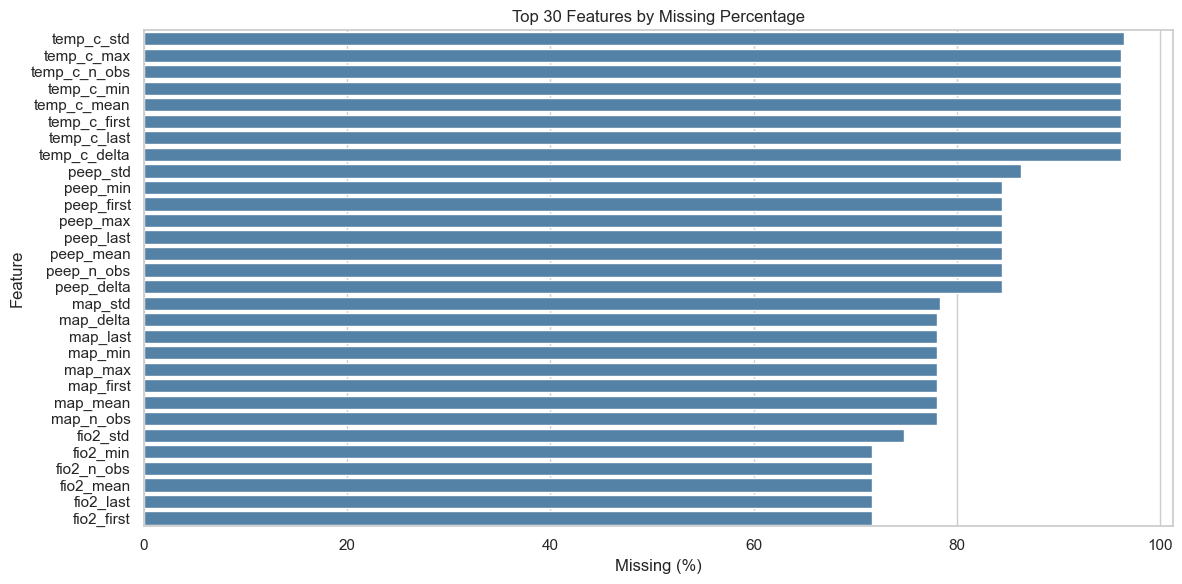

In [17]:
# Missingness visuals
if msno is None:
    print('missingno is not installed; skip this cell or run install cell.')
else:
    sample_df = df.sample(min(len(df), 2000), random_state=42)
    if df.shape[1] <= 40:
        msno.matrix(sample_df)
        plt.title('Missingness Matrix (sample)')
        plt.show()
        msno.heatmap(df)
        plt.title('Missingness Correlation')
        plt.show()
    else:
        missing_pct = df.isna().mean().sort_values(ascending=False).head(30) * 100
        plt.figure(figsize=(12, 6))
        sns.barplot(x=missing_pct.values, y=missing_pct.index, color='steelblue')
        plt.title('Top 30 Features by Missing Percentage')
        plt.xlabel('Missing (%)')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()

Numeric columns: 152


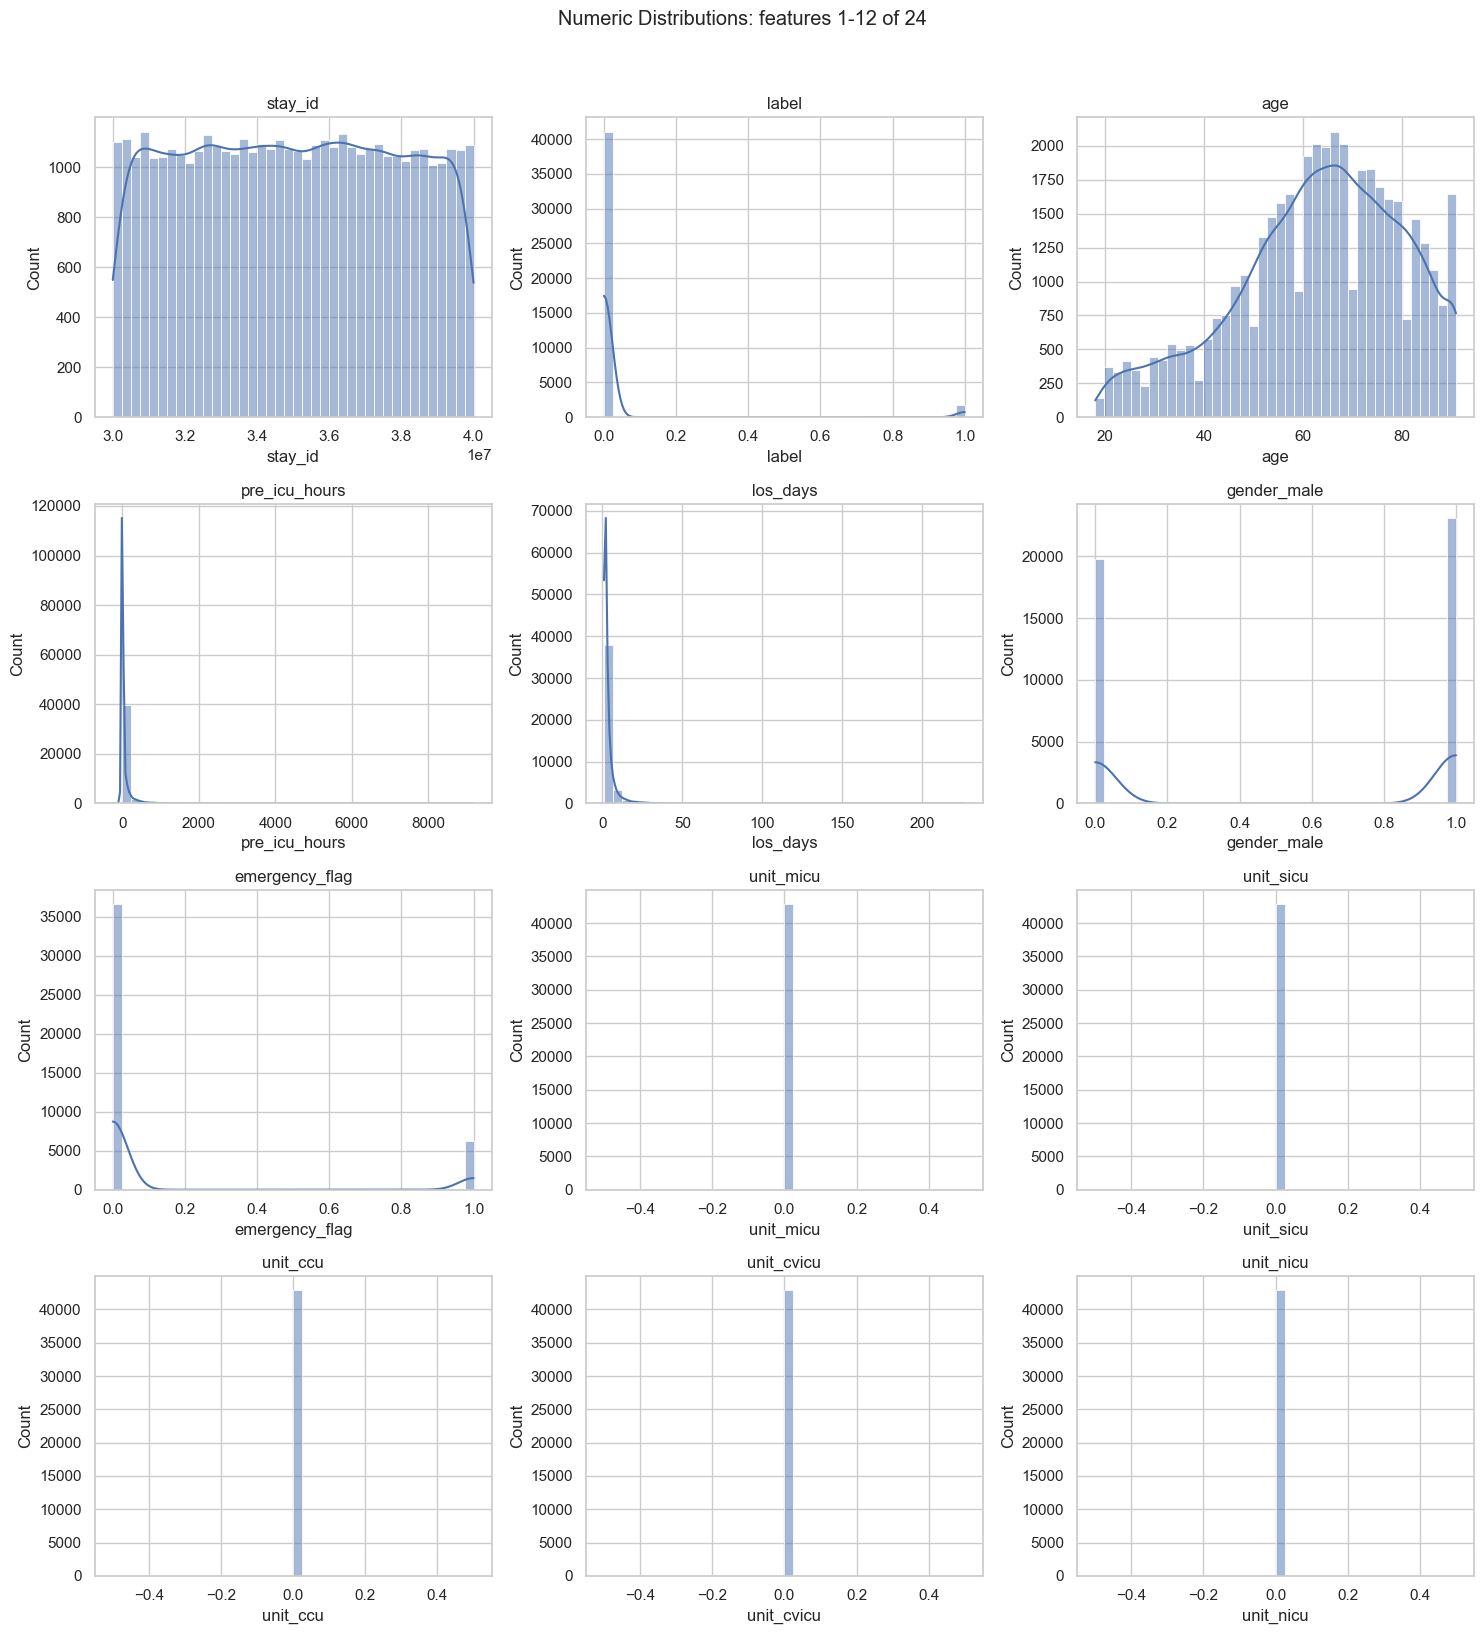

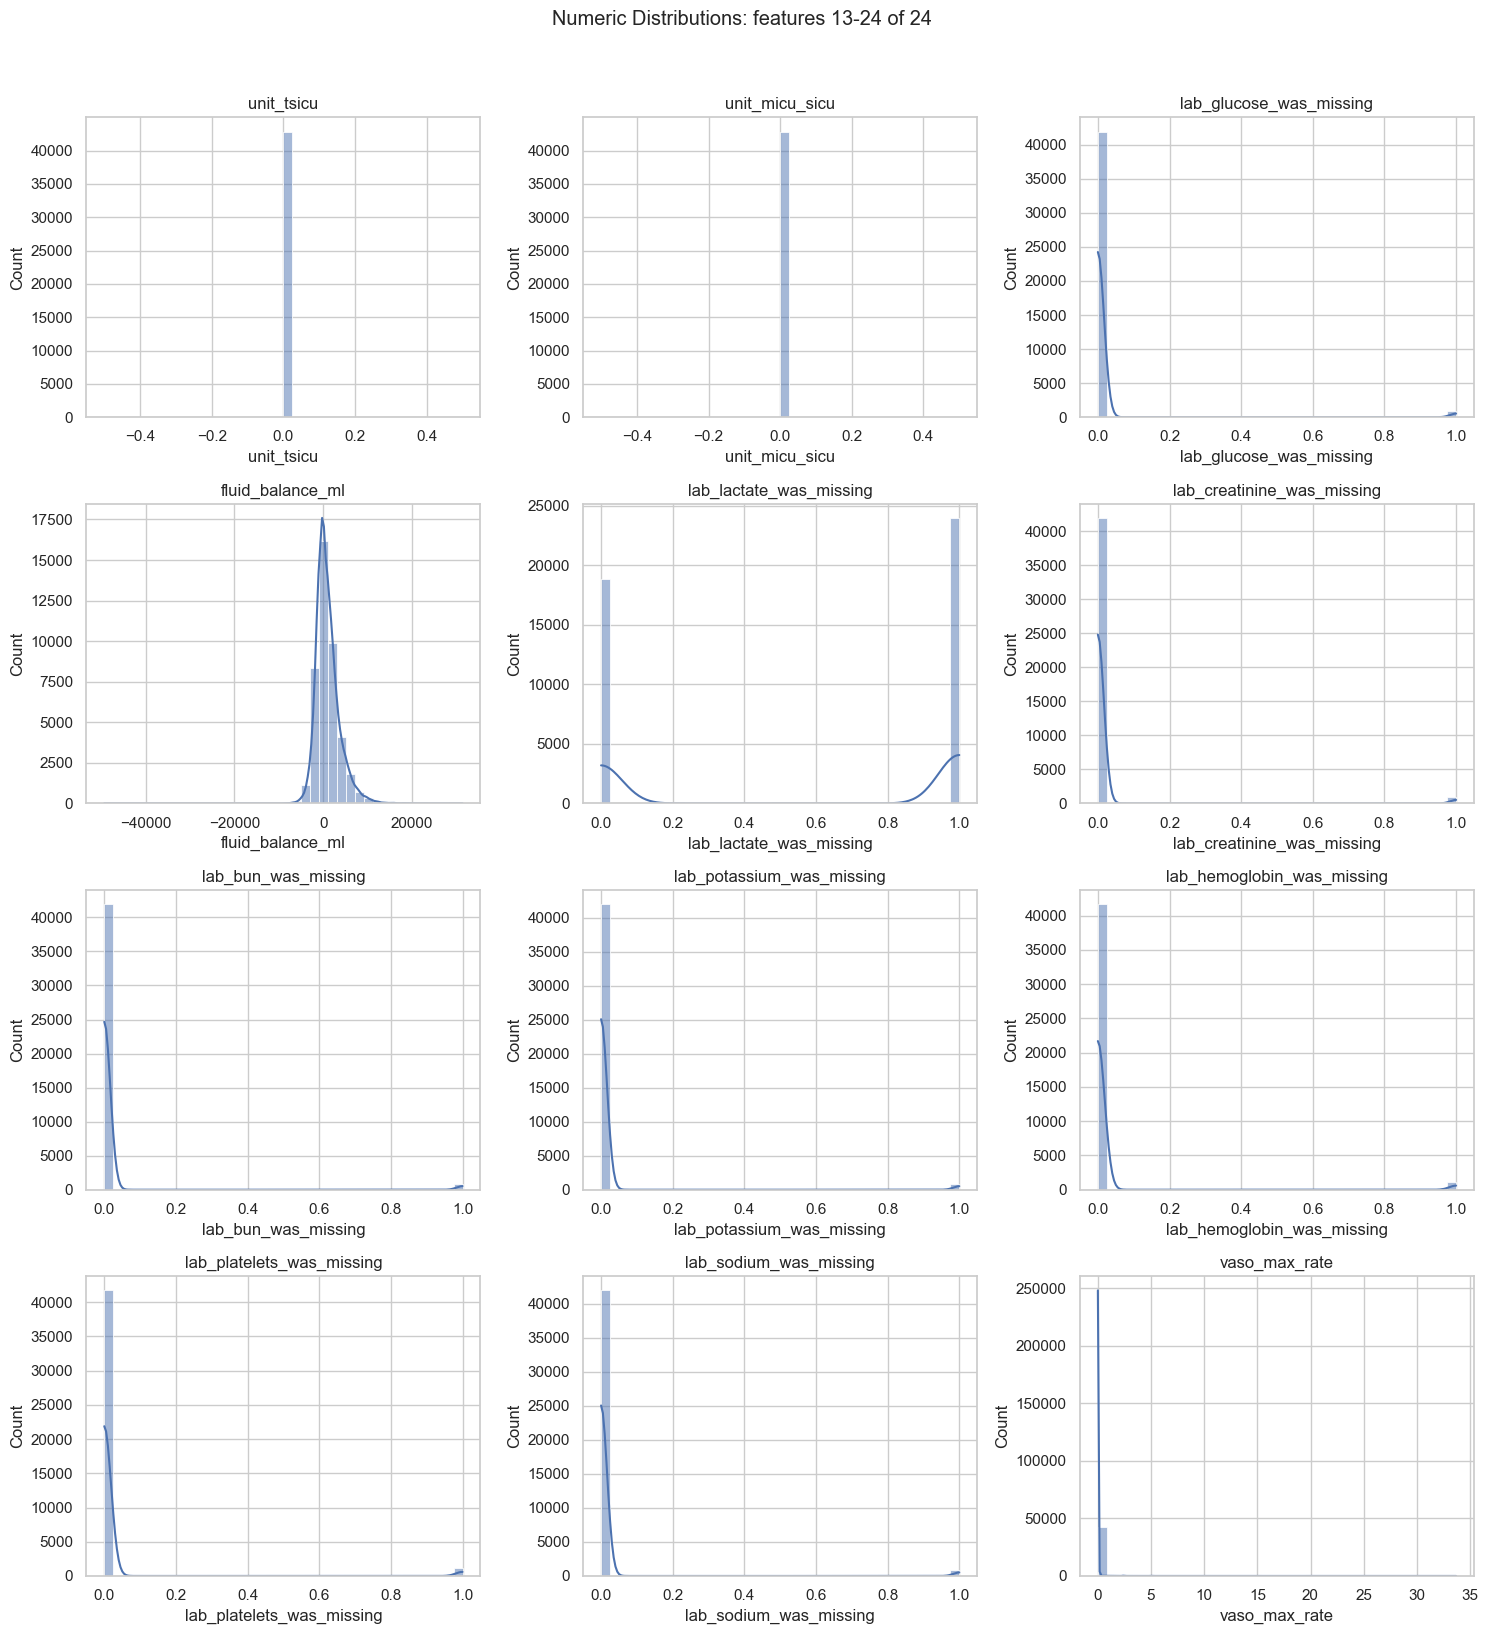

In [18]:
# Numeric feature distributions
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', len(num_cols))

def plot_numeric_batches(frame, columns, batch_size=12):
    if not columns:
        print('No numeric columns found.')
        return

    for start in range(0, len(columns), batch_size):
        batch = columns[start:start + batch_size]
        n = len(batch)
        ncols = 3
        nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
        axes = np.array(axes).reshape(-1)

        for i, col in enumerate(batch):
            sns.histplot(frame[col].dropna(), bins=40, kde=True, ax=axes[i])
            axes[i].set_title(col)

        for j in range(len(batch), len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Numeric Distributions: features {start + 1}-{start + len(batch)} of {len(columns)}', y=1.02)
        plt.tight_layout()
        plt.show()

if num_cols:
    ranked_numeric = df[num_cols].notna().sum().sort_values(ascending=False).index.tolist()
    cols_to_plot = ranked_numeric[:24]
    plot_numeric_batches(df, cols_to_plot, batch_size=12)
else:
    print('No numeric columns found.')

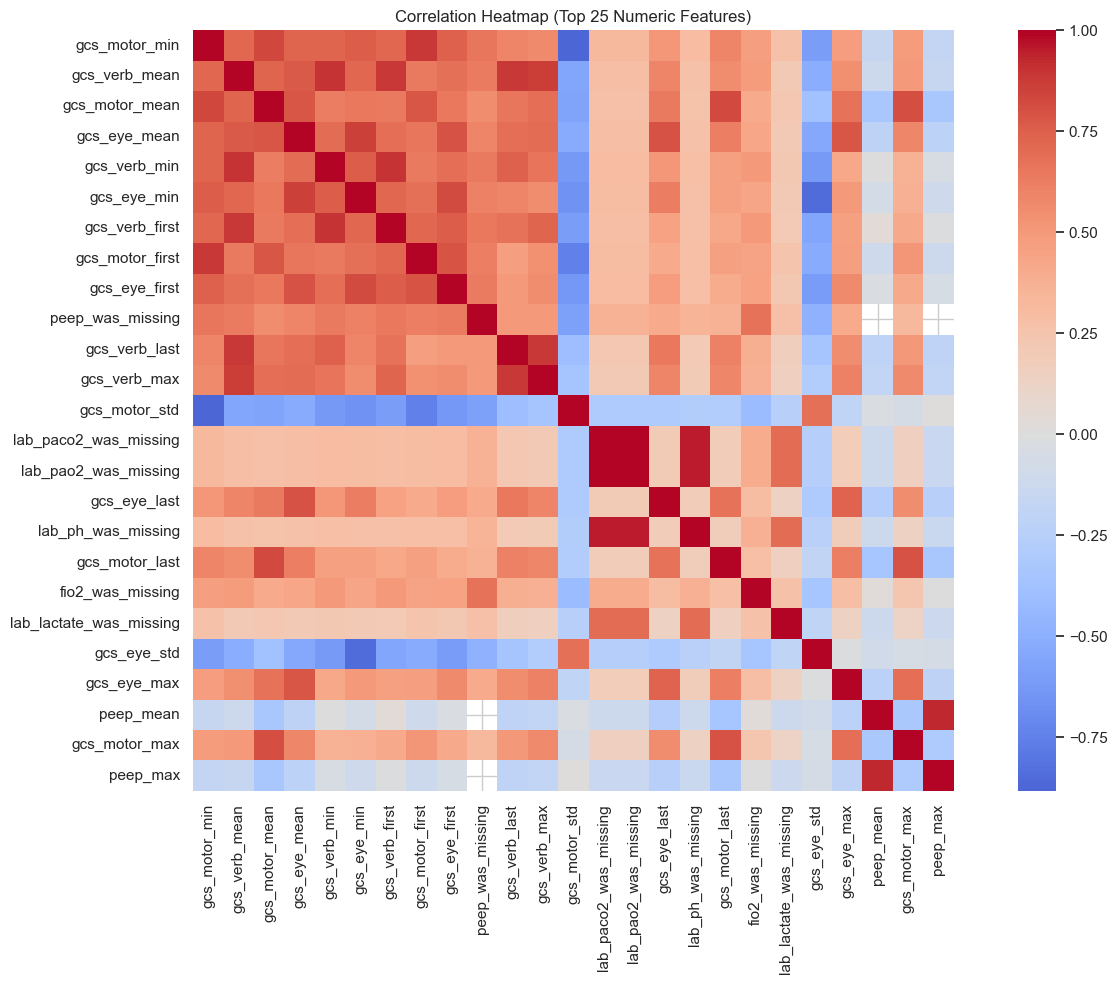

In [19]:
# Correlation heatmap
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)
    top_features = corr.abs().sum().sort_values(ascending=False).head(25).index
    plt.figure(figsize=(14, 10))
    sns.heatmap(df[top_features].corr(), cmap='coolwarm', center=0, square=True)
    plt.title('Correlation Heatmap (Top 25 Numeric Features)')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric features to compute correlation.')

In [20]:
# Candidate label exploration
candidate_labels = [
    'target', 'label', 'outcome', 'event', 'deteriorated', 'icu_deterioration'
]
found_labels = [c for c in df.columns if c.lower() in candidate_labels]

if not found_labels:
    low_cardinality = [c for c in df.columns if df[c].nunique(dropna=True) <= 5]
    found_labels = low_cardinality[:3]

print('Candidate label columns:', found_labels)
for col in found_labels:
    print('\nValue counts for', col)
    display(df[col].value_counts(dropna=False))

Candidate label columns: ['label']

Value counts for label


label
0    41087
1     1750
Name: count, dtype: int64

In [ ]:
# Leakage & prediction-time availability checks
leakage_warnings = []
# Check for obvious leakage columns
for cname in df.columns:
    low = cname.lower()
    if 'los' in low and 'day' in low:
        leakage_warnings.append((cname, 'contains los/days - check if known at prediction time'))
    if any(k in low for k in ['future', 'after', 'next', 'post', 'until']):
        leakage_warnings.append((cname, 'name suggests future or post-event info'))
    if any(agg in low for agg in ['_max', 'max_', '_min', 'min_', '_mean', 'mean_']):
        # mark aggregated-looking vars for manual audit
        leakage_warnings.append((cname, 'aggregated-looking name - verify aggregation window'))

if leakage_warnings:
    print('Potential leakage candidates (name-based heuristic):')
    for w in leakage_warnings:
        print('-', w[0], ':', w[1])
else:
    print('No obvious name-based leakage candidates found.')

# Check los_days presence and basic stats
for name in ['los_days', 'los', 'length_of_stay']:
    if name in df.columns:
        print(f'Column {name} present — summary:')
        display(df[name].describe())

# Sanity: are any columns completely constant or identical to label (if found)?
if found_labels:
    lbl = found_labels[0]
    for cname in df.columns:
        if cname == lbl:
            continue
        try:
            if df[cname].nunique(dropna=True) == df[lbl].nunique(dropna=True) and df[cname].dropna().equals(df[lbl].dropna()):
                print('Warning: feature', cname, 'matches label exactly — possible leakage')
        except Exception:
            pass

print('Leakage check complete — manually review flagged items.')

In [ ]:
# Drop very high-missing temperature variables and add ventilator missing flags
temp_cols = ['temp_c_first', 'temp_c_min', 'temp_c_max', 'temp_c_mean']
existing_temp = [c for c in temp_cols if c in df.columns]
for c in existing_temp:
    miss_frac = df[c].isna().mean()
    print(f'{c}: missing fraction={miss_frac:.3f}')
    if miss_frac >= 0.9:
        df.drop(columns=[c], inplace=True)
        print('Dropped', c)

# Ventilator-related flags (fio2, peep, map) - find columns and create was_missing flags
vent_keywords = ['fio2', 'peep', 'map']
for key in vent_keywords:
    cols = [c for c in df.columns if key in c.lower()]
    if cols:
        main = cols[0]
        flag = main + '_was_missing'
        df[flag] = df[main].isna()
        print('Added missing flag for', main)
    else:
        print('No column found for', key)

In [ ]:
# Median imputation + missing flag for select labs (lactate, bilirubin, pao2)
lab_keywords = ['lactate', 'bilirubin', 'pao2', 'pa_o2', 'pao_2']
for kw in lab_keywords:
    cols = [c for c in df.columns if kw in c.lower()]
    for c in cols:
        flag = c + '_was_missing'
        df[flag] = df[c].isna()
        median = df[c].median()
        df[c].fillna(median, inplace=True)
        print(f'Imputed {c} with median={median} and added {flag}')

# Log-transform suggestions for numeric skewed features
for col in ['pre_icu_hours', 'los_days']:
    if col in df.columns:
        new = col + '_log1p'
        df[new] = np.log1p(df[col].fillna(0))
        print('Created', new)

# Vaso max rate log variant
vaso_cols = [c for c in df.columns if 'vaso' in c.lower() and 'rate' in c.lower()]
for c in vaso_cols:
    df[c + '_log1p'] = np.log1p(df[c].abs().fillna(0))
    print('Created log1p for', c)

In [ ]:
# Time feature extraction from 'intime' or common timestamp columns
time_cols = [c for c in df.columns if 'intime' in c.lower() or 'admit' in c.lower() or 'admission' in c.lower()]
if time_cols:
    tcol = time_cols[0]
    print('Using', tcol, 'to extract time features')
    df[tcol] = pd.to_datetime(df[tcol], errors='coerce')
    df['hour_of_day'] = df[tcol].dt.hour
    df['day_of_week'] = df[tcol].dt.dayofweek
    df['month'] = df[tcol].dt.month
    df['is_weekend'] = df['day_of_week'].isin([5,6])
    df['is_night'] = df['hour_of_day'].isin(list(range(0,7)) + [23])
    print('Extracted hour_of_day, day_of_week, month, is_weekend, is_night')
    # drop raw timestamp if desired (commented out — uncomment to drop)
    # df.drop(columns=[tcol], inplace=True)
else:
    print('No admission/intime column found for time feature extraction')

In [ ]:
# GCS total features from eye/verbal/motor components if present
eye_cols = [c for c in df.columns if 'eye' in c.lower() and 'gcs' in c.lower()]
verb_cols = [c for c in df.columns if ('verbal' in c.lower() or 'verbal' in c.lower()) and 'gcs' in c.lower()]
motor_cols = [c for c in df.columns if 'motor' in c.lower() and 'gcs' in c.lower()]
# fallback patterns
if not eye_cols:
    eye_cols = [c for c in df.columns if 'eye' in c.lower()]
if not verb_cols:
    verb_cols = [c for c in df.columns if 'verbal' in c.lower() or 'verbal_response' in c.lower()]
if not motor_cols:
    motor_cols = [c for c in df.columns if 'motor' in c.lower()]

# Try to build gcs_total_first from *_first components
components_first = []
for comp in ['eye', 'verbal', 'motor']:
    cols = [c for c in df.columns if comp in c.lower() and ('first' in c.lower() or '_first' in c.lower())]
    if cols:
        components_first.append(cols[0])

if len(components_first) == 3:
    df['gcs_total_first'] = df[components_first].sum(axis=1)
    print('Created gcs_total_first from', components_first)
else:
    print('gcs component first-values not found; skipping gcs_total_first')

# Also create mean/min variants if component *_mean/_min exist
components_mean = []
for comp in ['eye', 'verbal', 'motor']:
    cols = [c for c in df.columns if comp in c.lower() and 'mean' in c.lower()]
    if cols:
        components_mean.append(cols[0])
if len(components_mean) == 3:
    df['gcs_total_mean'] = df[components_mean].mean(axis=1)
    print('Created gcs_total_mean from', components_mean)

# Summary: print new columns created
new_cols = [c for c in df.columns if c.endswith('_was_missing') or c.endswith('_log1p') or c.startswith('gcs_total') or c in ['hour_of_day','day_of_week','month','is_weekend','is_night']]
print('New/generated columns:', new_cols)

## Modeling notes & recommended next steps

- Priority #1: manual leakage audit of flagged features from the leakage checks cell. Ensure all features are available at prediction time and aggregations don't use future data.
- Data cleaning: dropped temperature vars with >90% missingness; created missing flags for vent-related vars and imputed select labs (median + missing flag).
- Transformations: used `log1p` for skewed duration features and vaso rates.
- Time features: extracted `hour_of_day`, `day_of_week`, `month`, `is_weekend`, and `is_night` from admission timestamps.
- GCS: computed `gcs_total_first` / `gcs_total_mean` when components available; prefer interpretable totals over PCA unless necessary.
- Modeling roadmap: baseline logistic regression with `class_weight='balanced'`, then XGBoost/LightGBM with `scale_pos_weight` and careful threshold tuning.
- Metrics: track ROC-AUC, PR-AUC, Brier score, and operating-point metrics (recall at fixed FPR or recall at target precision).

Run the previous cells and review flagged items before proceeding to modeling.

## EDA Findings Checklist

- Identify high-missing columns and define imputation/removal strategy.
- Confirm the true target column and class balance.
- Flag skewed/outlier-heavy numeric features for transformation.
- Select candidate features for modeling in the next phase.